Import Libraries

In [199]:
# 🔧 TOOLS WE NEED
# Think of these like apps you install before using them

import numpy as np                          # For number crunching
import pandas as pd                         # For tables (like Excel)
import matplotlib.pyplot as plt             # For drawing charts
import seaborn as sns                       # For prettier charts
import warnings
warnings.filterwarnings('ignore')


# Data preparation
from sklearn.preprocessing import StandardScaler

# The 3 clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Dimensionality reduction (to visualize)
from sklearn.decomposition import PCA

# Measuring how good our clusters are
from sklearn.metrics import silhouette_score

# For drawing the tree diagram
from scipy.cluster.hierarchy import dendrogram, linkage

# Visual settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

print('✅ All set! Ready to go.')

✅ All set! Ready to go.


Step 1: Data Collection

Load Dataset

In [200]:
appuser=pd.read_csv('/content/app_user_behavior_dataset.csv')
appuser.head()

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


In [201]:
appuser.shape

(50000, 25)

Step 2: Data Understanding


In [202]:
#check column names
appuser.columns

Index(['user_id', 'age', 'gender', 'country', 'device_type', 'app_version',
       'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'subscription_type',
       'ads_clicked_last_30_days', 'content_downloads', 'social_shares',
       'rating_given', 'churn_risk_score', 'engagement_score',
       'account_age_days', 'marketing_source'],
      dtype='object')

In [203]:
#Dataset Information (data types & non-null values)
appuser.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [204]:
##Null Value Distribution Analysis
#check total number of missing values in the entire dataset
appuser.isnull().sum().sum()

np.int64(5022)

In [205]:
#Statistical Summary
appuser.describe()

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,44978.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,22.038240,5.995800,3.002260,2.001440,3.630664,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.985237,2.453313,1.731818,1.413435,1.087339,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


In [206]:
#Check Missing Values
appuser.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
device_type,0
app_version,0
sessions_per_week,0
avg_session_duration_min,0
daily_active_minutes,0
feature_clicks_per_session,0


In [207]:
#Check Categorical Columns
appuser.select_dtypes(include='object').columns

Index(['gender', 'country', 'device_type', 'subscription_type',
       'marketing_source'],
      dtype='object')

In [208]:
#Check Unique Values (Categorical Columns)
#(Shows Unique Values + Count)
for col in appuser.select_dtypes(include='object').columns:
    display(appuser[col].value_counts())

,count
gender,
Female,23994
Male,23936
Other,2070


,count
country,
India,22550
USA,9115
UK,5043
Canada,3853
Australia,3498
Germany,3425
Singapore,2516


,count
device_type,
Android,27315
iOS,17662
Web,5023


,count
subscription_type,
Free,30088
Basic,12495
Premium,7417


,count
marketing_source,
Organic,17539
Google Ads,12468
Referral,7539
Facebook Ads,7463
Email Campaign,4991


In [209]:
#Check Duplicate Rows
appuser.duplicated().sum()

np.int64(0)

STEP 3: Data Cleaning & Preprocessing

In [210]:
# Select numerical columns
numerical_columns = appuser.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['user_id', 'age', 'app_version', 'sessions_per_week',
       'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'ads_clicked_last_30_days',
       'content_downloads', 'social_shares', 'rating_given',
       'churn_risk_score', 'engagement_score', 'account_age_days'],
      dtype='object')


In [211]:
print("Number of Numerical Columns:", len(numerical_columns))

Number of Numerical Columns: 20


In [212]:
# Select categorical columns
categorical_columns = appuser.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['gender', 'country', 'device_type', 'subscription_type',
       'marketing_source'],
      dtype='object')


In [213]:
print("Number of Categorical Columns:", len(categorical_columns))

Number of Categorical Columns: 5


In [214]:
appuser['rating_given'].describe()

,rating_given
count,44978.000000
mean,3.630664
std,1.087339
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


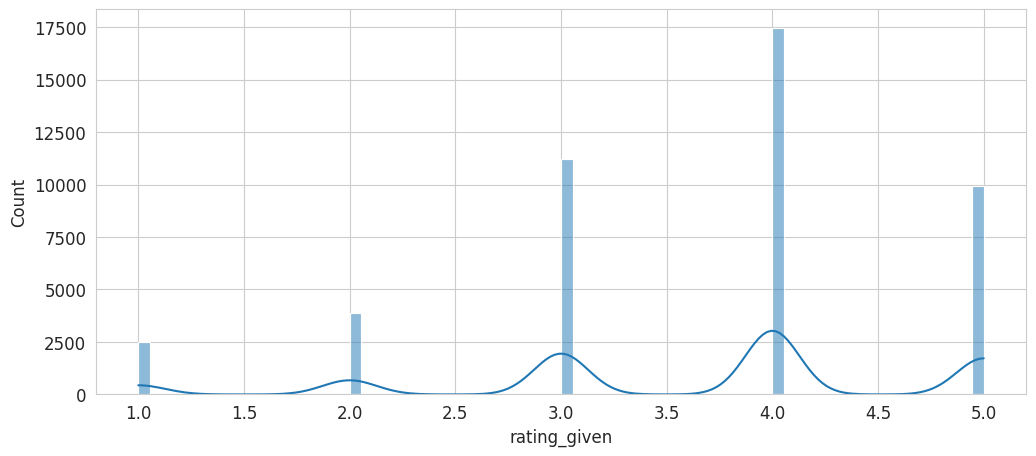

In [215]:
#check skewed
sns.histplot(appuser['rating_given'], kde=True)
plt.show()

Explanation

The rating variable is discrete and slightly negatively skewed with more high-value observations, I used median imputation to preserve the central tendency without being affected by skewness.

In [216]:
#Skewness Value (Numerical Check)
appuser['rating_given'].skew()


np.float64(-0.6774289656424688)

Interpretation:

Negative value → Left-skewed distribution

Tail is on the left side (lower values like 1, 2)

Majority of data is on the right side (higher values like 4, 5)

In [217]:
#Median fill
appuser['rating_given'] = appuser['rating_given'].fillna(appuser['rating_given'].median())

In [218]:
#Check Missing Values
appuser['rating_given'].isnull().sum()

np.int64(0)

In [219]:
#Check Entire Dataset
appuser.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
device_type,0
app_version,0
sessions_per_week,0
avg_session_duration_min,0
daily_active_minutes,0
feature_clicks_per_session,0


In [220]:
#Verify Median Replacement Worked
appuser['rating_given'].describe()

,rating_given
count,50000.000000
mean,3.667760
std,1.037245
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


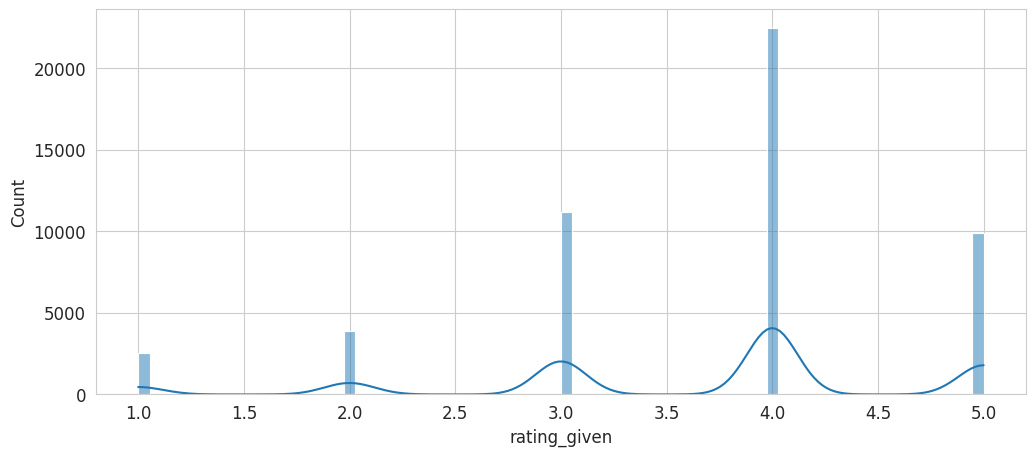

In [221]:
#Visual Check again
sns.histplot(appuser['rating_given'], kde=True)
plt.show()

In [222]:
#Ensure Consistency in Categorical Data
for col in categorical_columns:
    appuser[col] = appuser[col].str.strip().str.lower()

In [223]:
#clean inconsistent labels
cat_cols = appuser.select_dtypes(include='object').columns

for col in cat_cols:
    appuser[col] = appuser[col].str.lower().str.strip()
cat_cols = appuser.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, ":", appuser[col].unique())

gender : ['female' 'male' 'other']
country : ['india' 'uk' 'australia' 'germany' 'singapore' 'canada' 'usa']
device_type : ['ios' 'android' 'web']
subscription_type : ['basic' 'free' 'premium']
marketing_source : ['referral' 'email campaign' 'google ads' 'organic' 'facebook ads']


In [224]:
#Check Value Counts
for col in categorical_columns:
    appuser[col].value_counts()

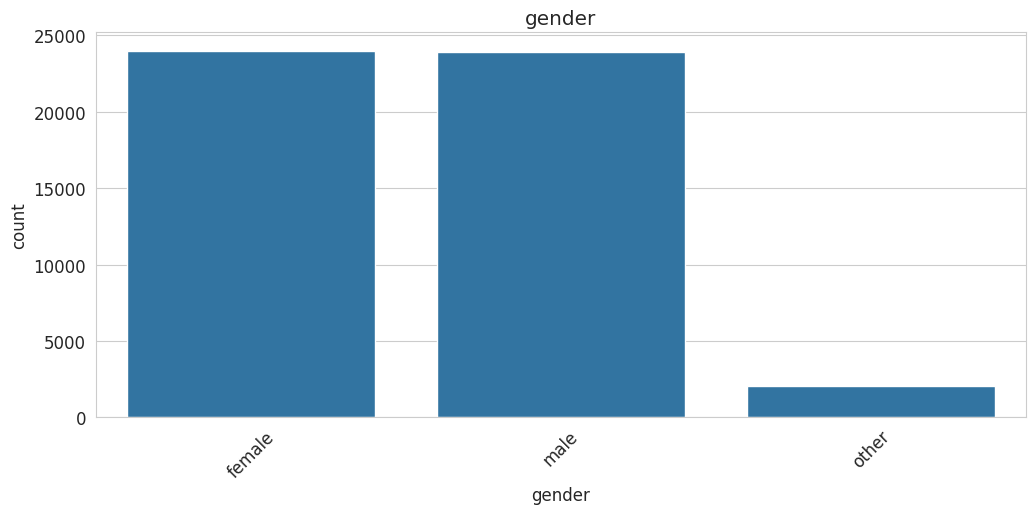

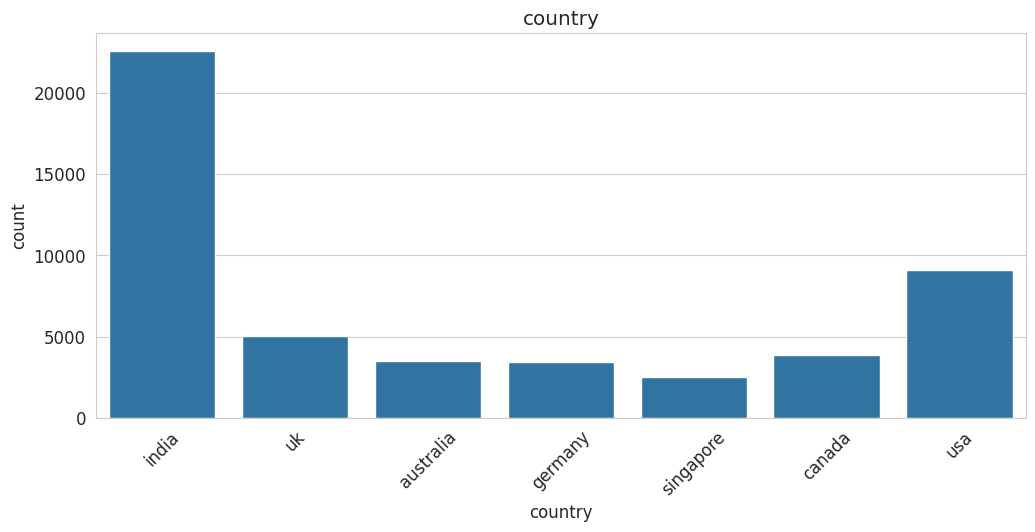

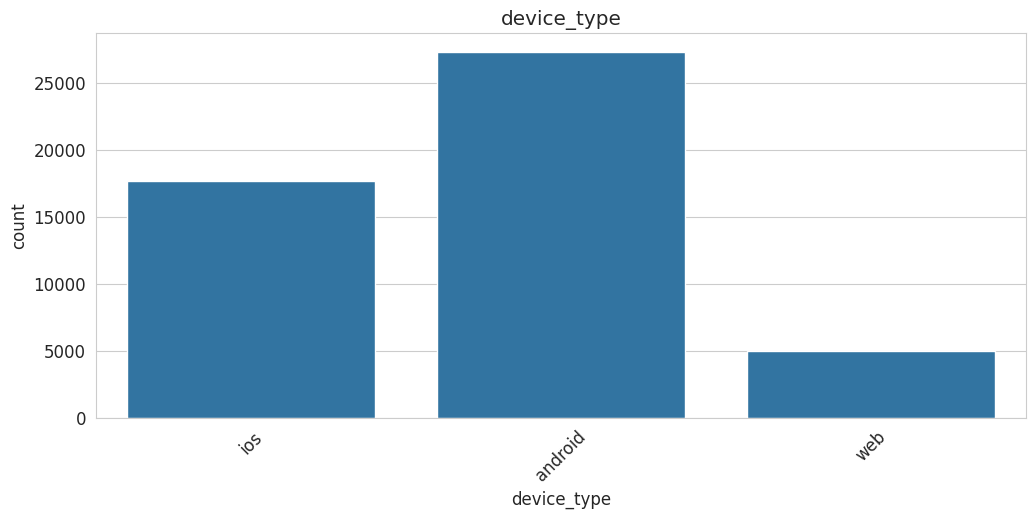

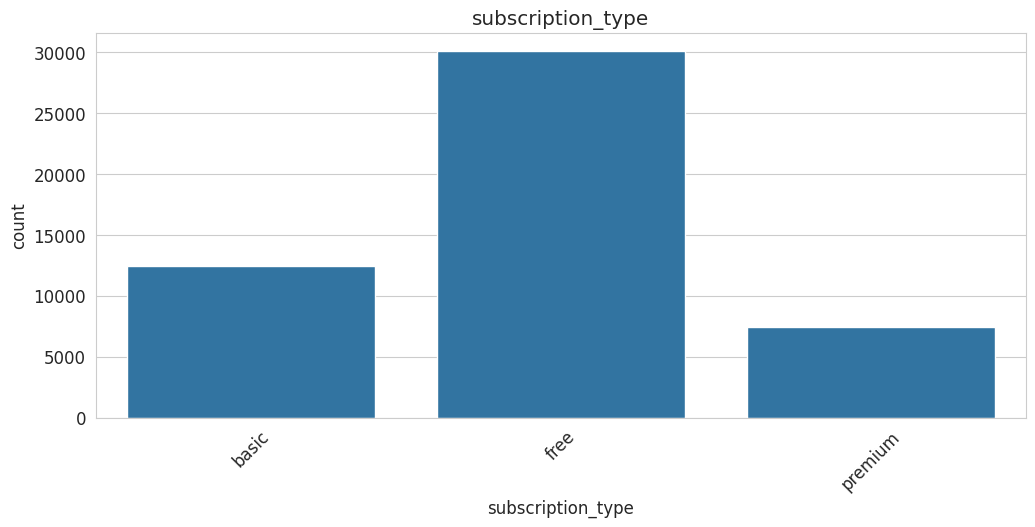

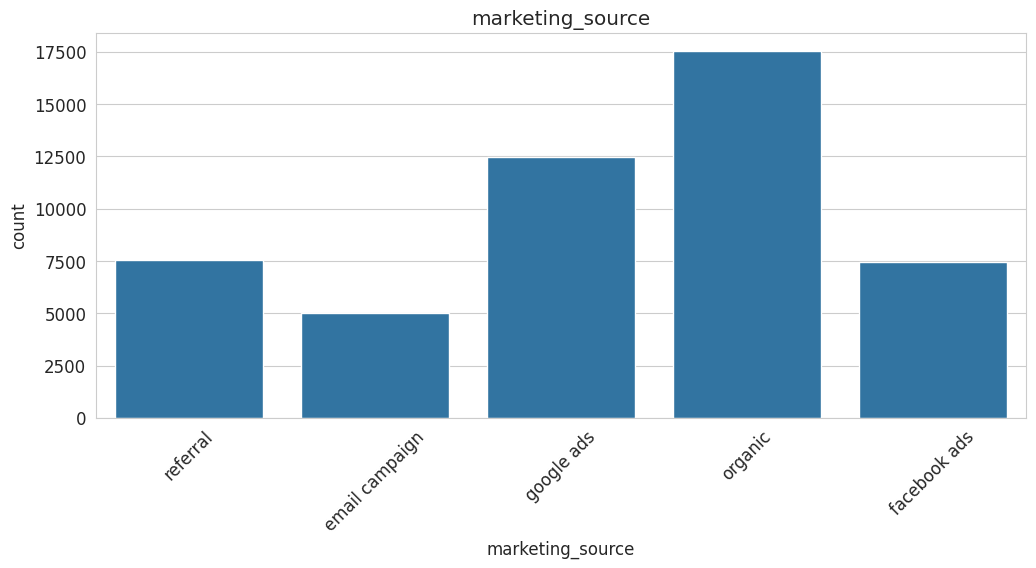

In [225]:
#Seaborn Countplot
for col in categorical_columns:
    sns.countplot(x=appuser[col])
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [226]:
#Checking outliers
#identify numerical columns
num_cols = appuser.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['user_id', 'age', 'app_version', 'sessions_per_week',
       'avg_session_duration_min', 'daily_active_minutes',
       'feature_clicks_per_session', 'notifications_opened_per_week',
       'in_app_search_count', 'pages_viewed_per_session',
       'crash_events_last_30_days', 'support_tickets_raised',
       'days_since_last_login', 'ads_clicked_last_30_days',
       'content_downloads', 'social_shares', 'rating_given',
       'churn_risk_score', 'engagement_score', 'account_age_days'],
      dtype='object')


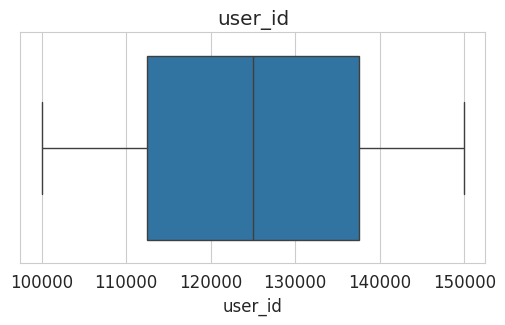

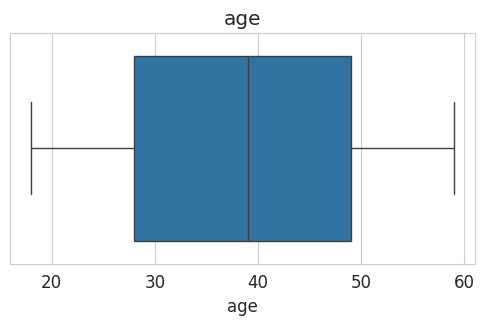

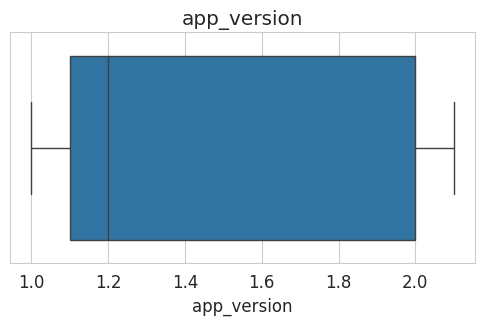

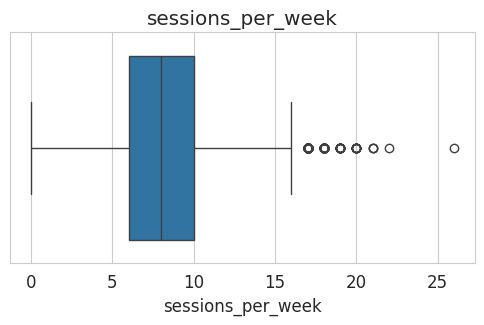

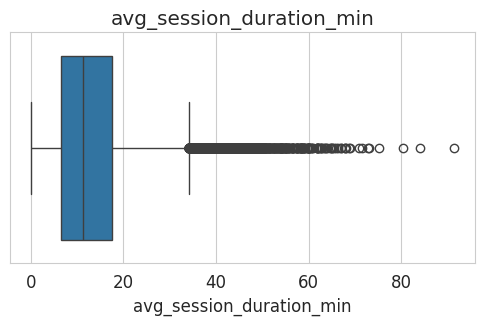

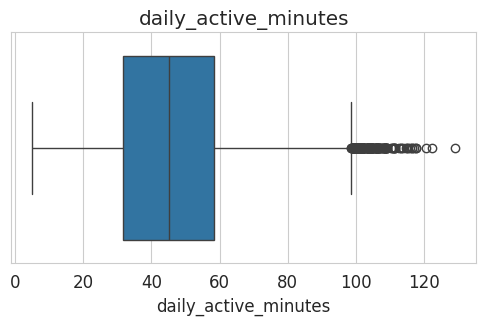

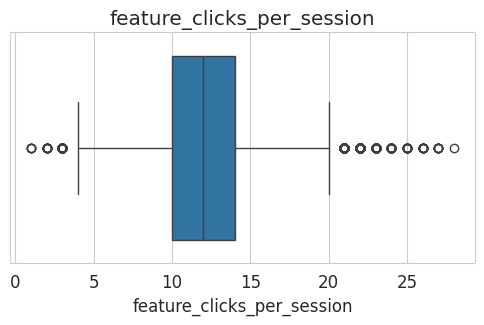

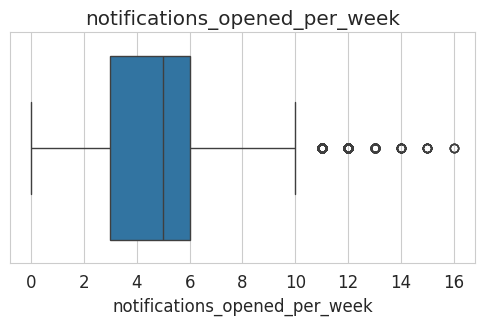

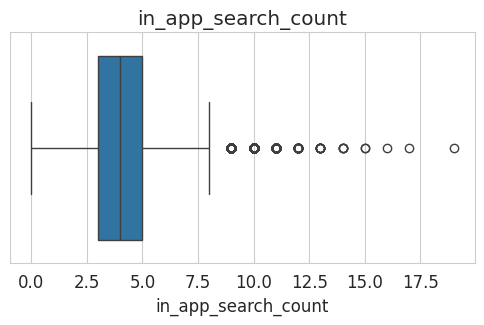

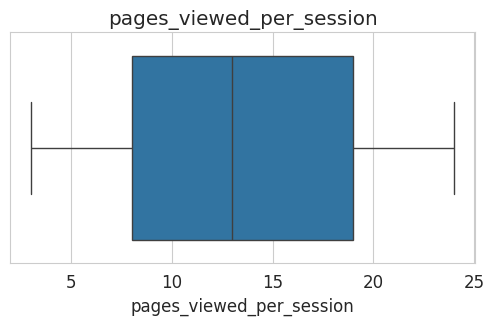

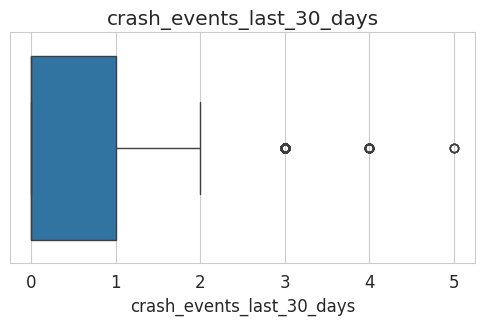

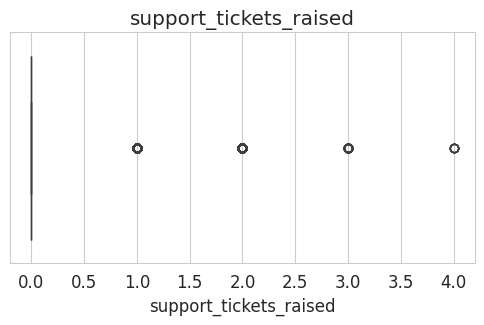

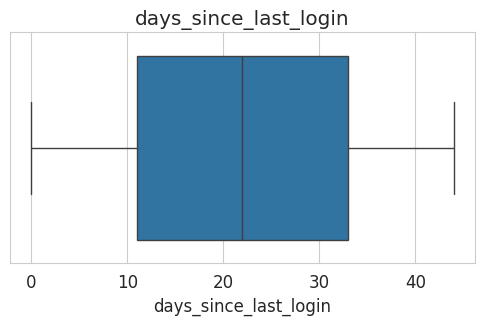

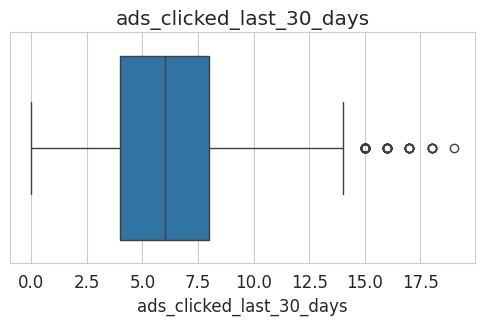

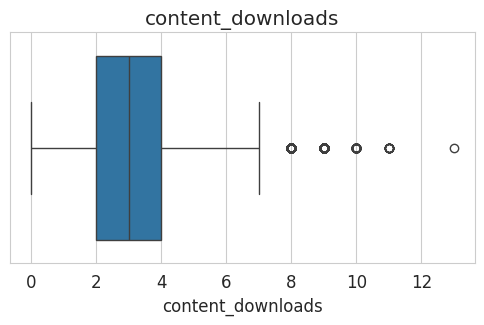

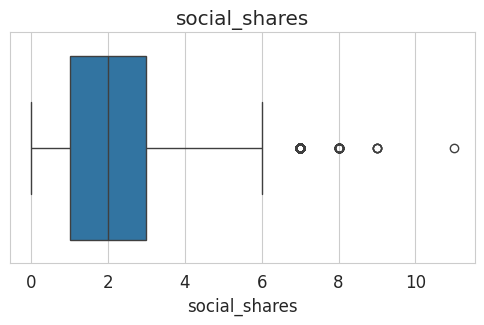

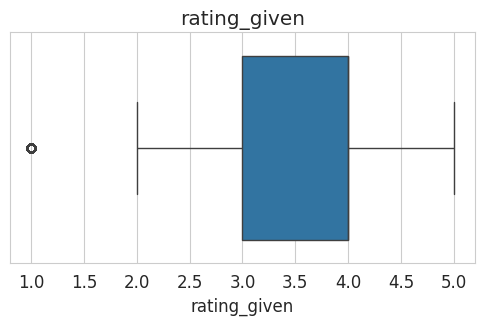

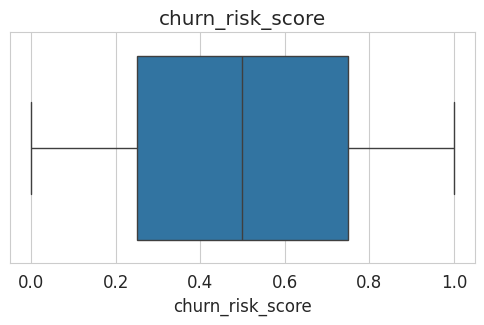

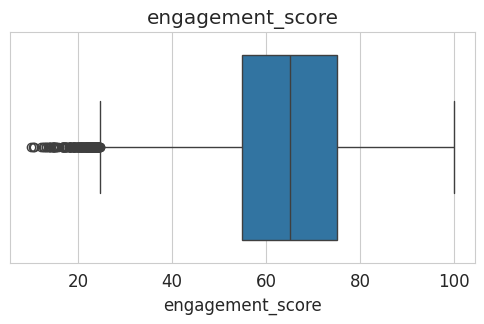

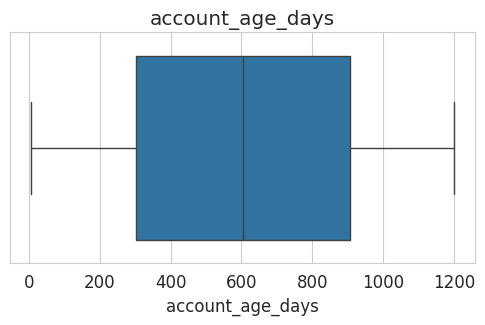

In [227]:
#Boxplot to visually check outliers

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=appuser[col])
    plt.title(col)
    plt.show()

In [228]:
#check outliers count
num_cols = appuser.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    Q1 = appuser[col].quantile(0.25)
    Q3 = appuser[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = appuser[(appuser[col] < lower) | (appuser[col] > upper)]

    print(col, ":", len(outliers))

user_id : 0
age : 0
app_version : 0
sessions_per_week : 181
avg_session_duration_min : 1572
daily_active_minutes : 181
feature_clicks_per_session : 745
notifications_opened_per_week : 660
in_app_search_count : 1054
pages_viewed_per_session : 0
crash_events_last_30_days : 398
support_tickets_raised : 8910
days_since_last_login : 0
ads_clicked_last_30_days : 70
content_downloads : 622
social_shares : 219
rating_given : 2518
churn_risk_score : 0
engagement_score : 167
account_age_days : 0


In [229]:
##Capping Only These Columns
outlier_cols = [
'sessions_per_week',
'avg_session_duration_min',
'daily_active_minutes',
'feature_clicks_per_session',
'notifications_opened_per_week',
'in_app_search_count',
'crash_events_last_30_days',
'support_tickets_raised',
'ads_clicked_last_30_days',
'content_downloads',
'social_shares'
]

In [230]:
for col in outlier_cols:
    Q1 = appuser[col].quantile(0.25)
    Q3 = appuser[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    appuser[col] = appuser[col].clip(lower_bound, upper_bound)

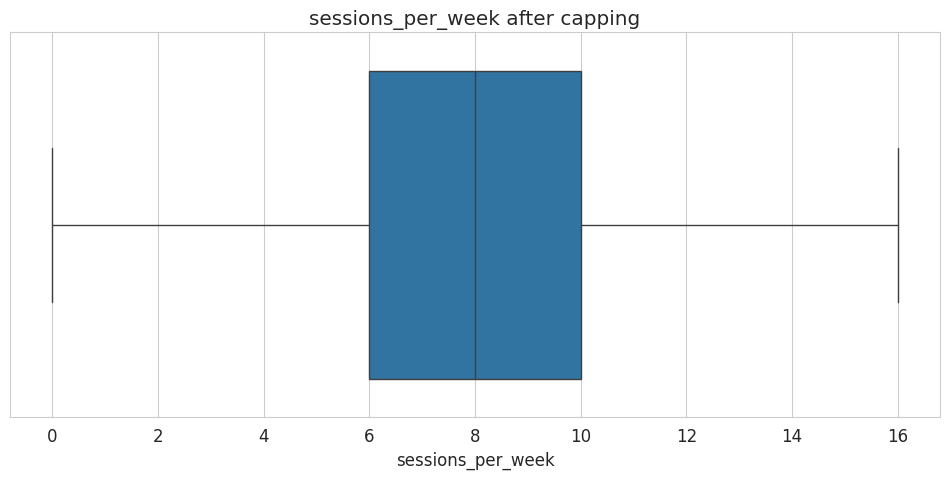

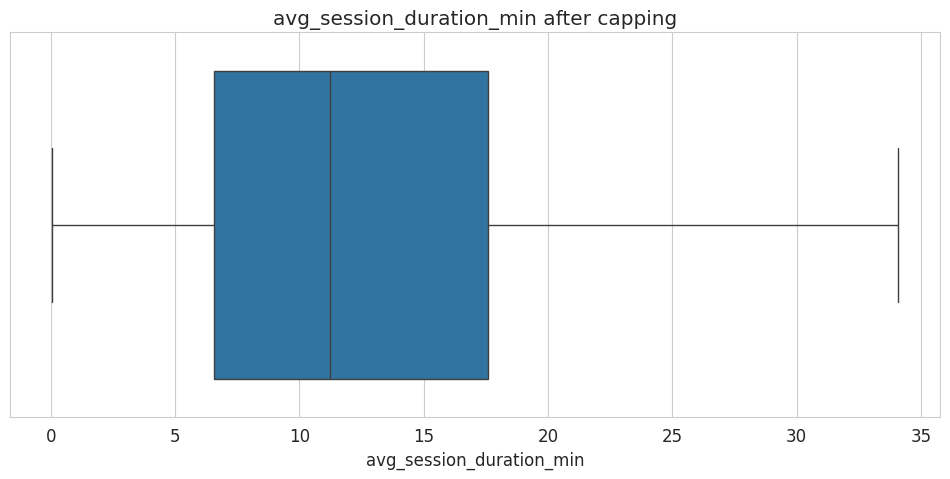

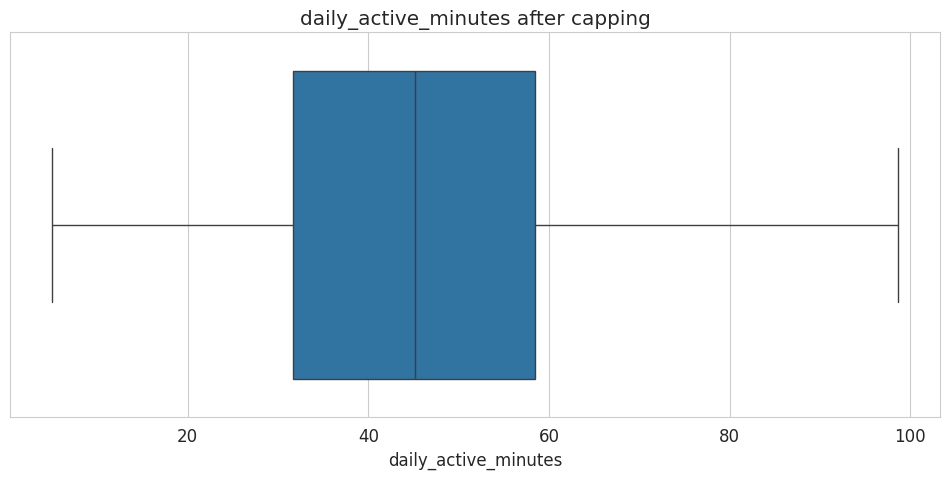

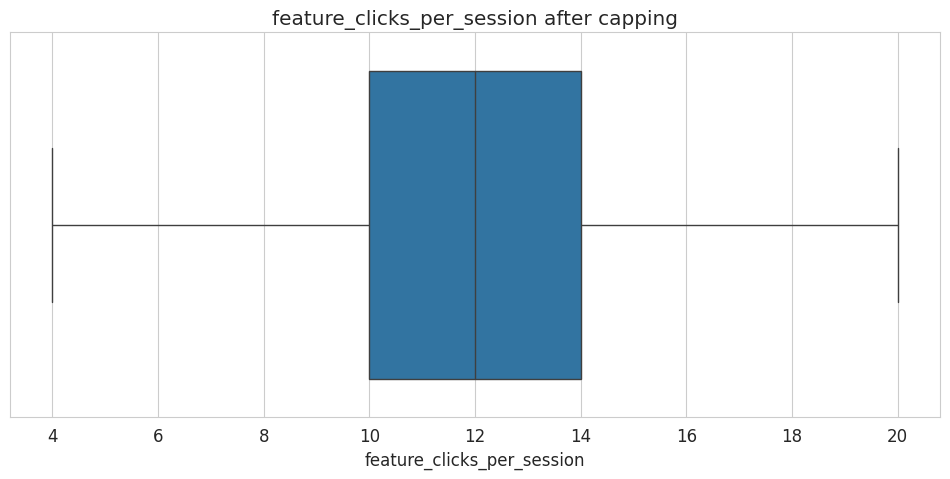

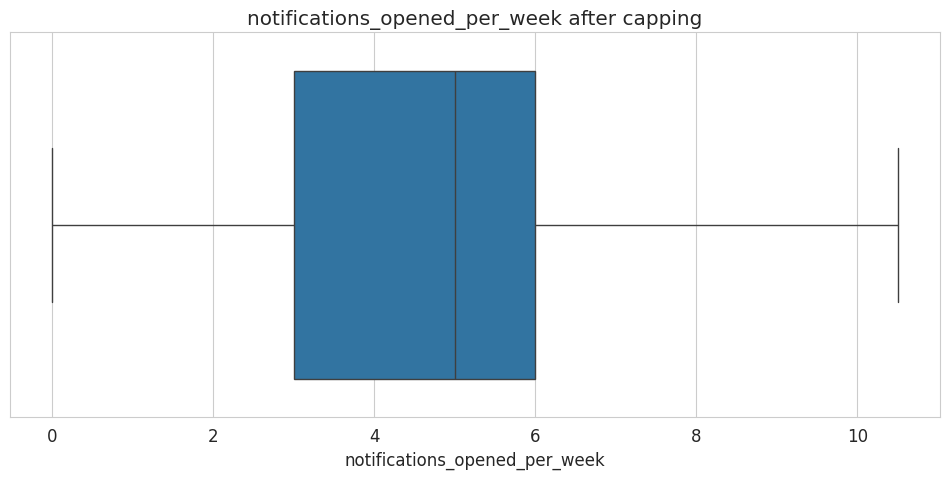

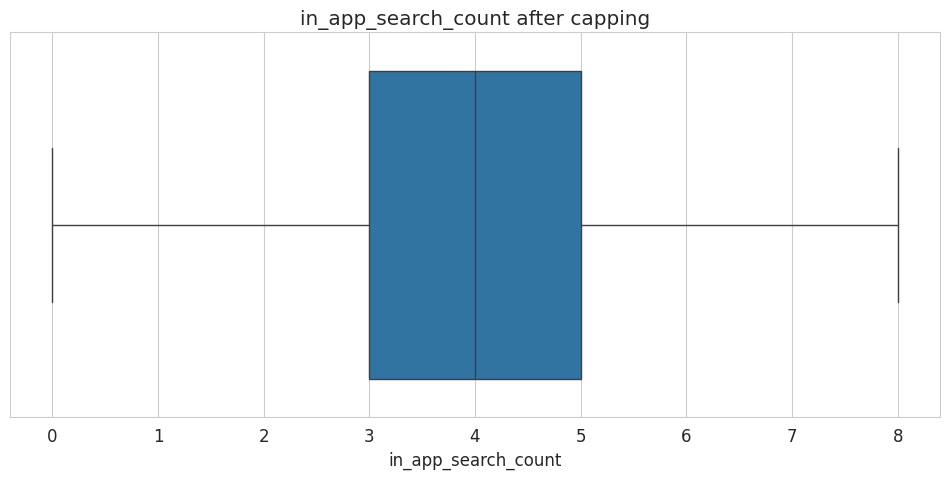

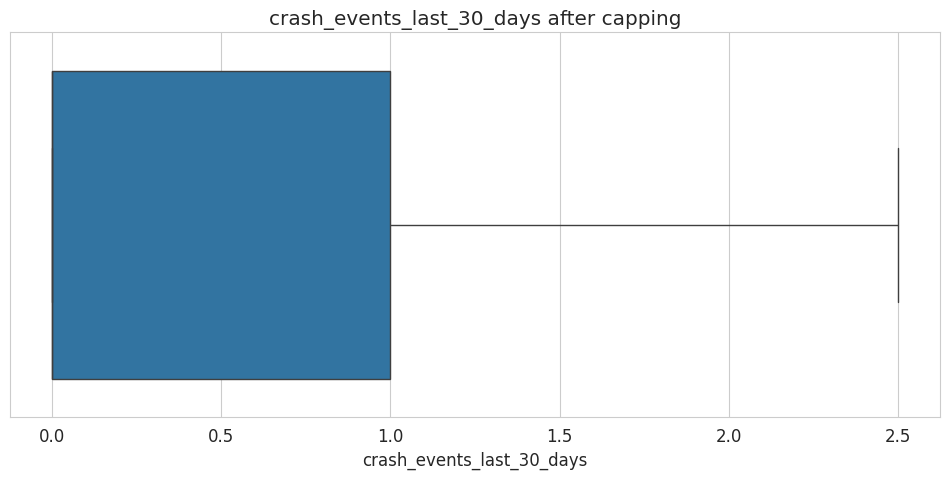

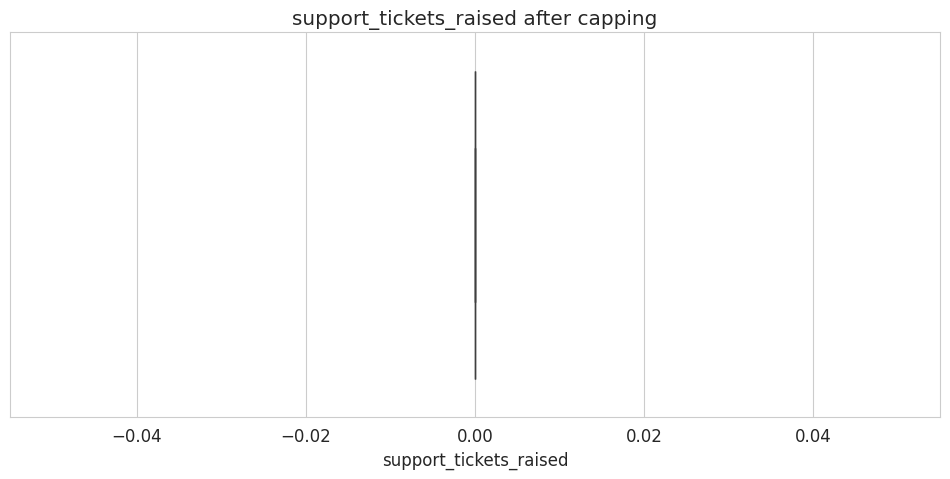

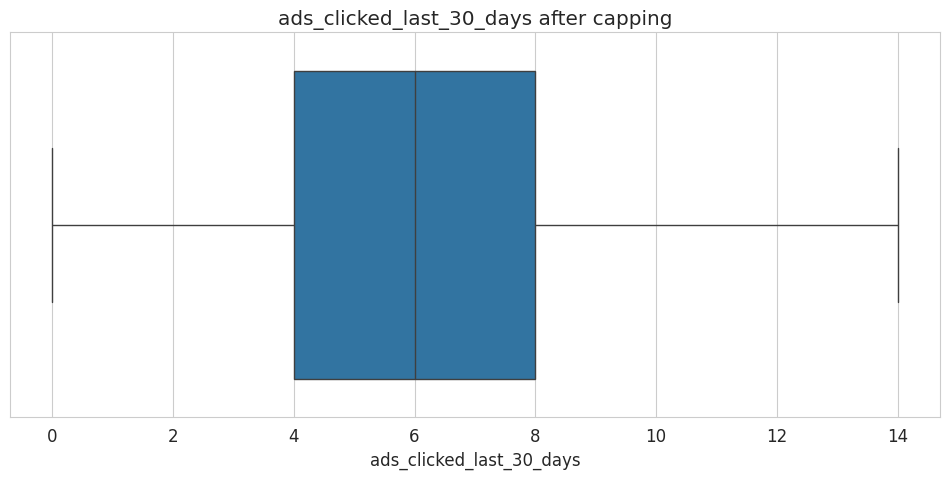

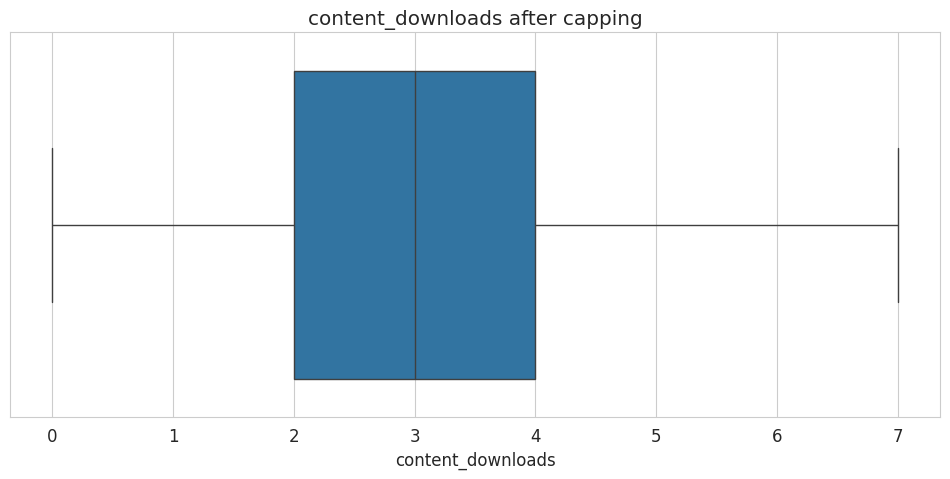

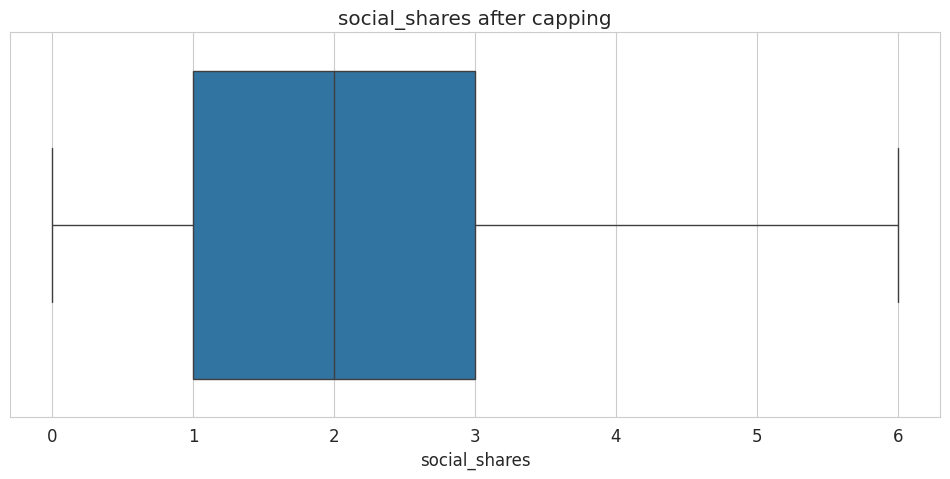

In [231]:
#4: Verify After Capping
for col in outlier_cols:
    sns.boxplot(x=appuser[col])
    plt.title(f"{col} after capping")
    plt.show()


In [232]:
#checking outliers after capping


num_cols = appuser.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = appuser[col].quantile(0.25)
    Q3 = appuser[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = appuser[(appuser[col] < lower) | (appuser[col] > upper)]

    print(col, ":", outliers.shape[0])

user_id : 0
age : 0
app_version : 0
sessions_per_week : 0
avg_session_duration_min : 0
daily_active_minutes : 0
feature_clicks_per_session : 0
notifications_opened_per_week : 0
in_app_search_count : 0
pages_viewed_per_session : 0
crash_events_last_30_days : 0
support_tickets_raised : 0
days_since_last_login : 0
ads_clicked_last_30_days : 0
content_downloads : 0
social_shares : 0
rating_given : 2518
churn_risk_score : 0
engagement_score : 167
account_age_days : 0


Explanation

I applied IQR-based capping on key behavioral features to handle outliers without removing data, ensuring the clustering model is not biased by extreme values.

In [233]:
#Special Columns Handling
#Drop user_id (not needed)
appuser = appuser.drop(columns=['user_id'])

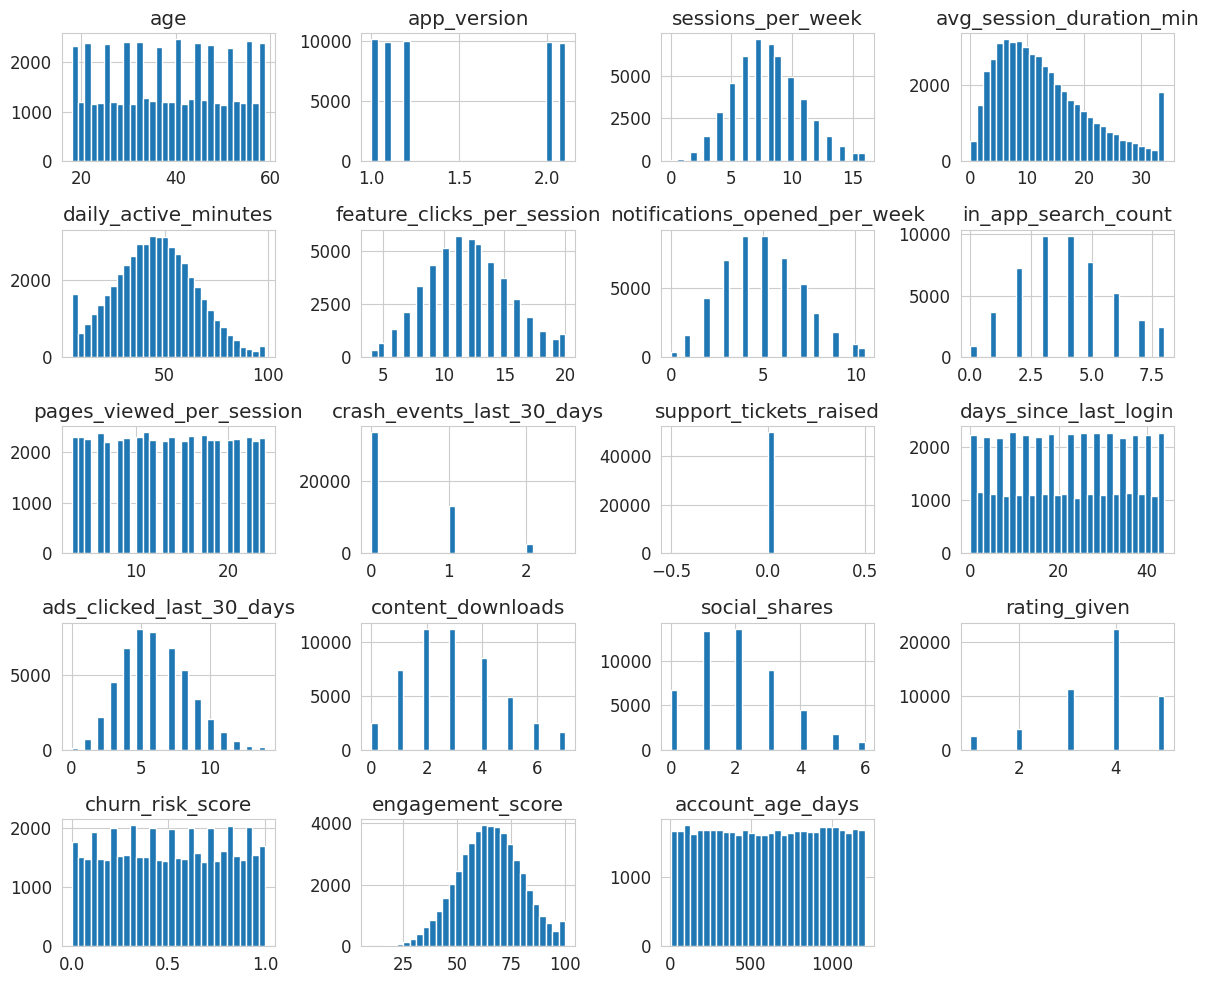

In [234]:
##Numerical feature distribution
#Even after capping, check how features are spread

numerical_cols = appuser.select_dtypes(include=['int64', 'float64']).columns

appuser[numerical_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

In [235]:
appuser.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   gender                         50000 non-null  object 
 2   country                        50000 non-null  object 
 3   device_type                    50000 non-null  object 
 4   app_version                    50000 non-null  float64
 5   sessions_per_week              50000 non-null  int64  
 6   avg_session_duration_min       50000 non-null  float64
 7   daily_active_minutes           50000 non-null  float64
 8   feature_clicks_per_session     50000 non-null  int64  
 9   notifications_opened_per_week  50000 non-null  float64
 10  in_app_search_count            50000 non-null  int64  
 11  pages_viewed_per_session       50000 non-null  int64  
 12  crash_events_last_30_days      50000 non-null 

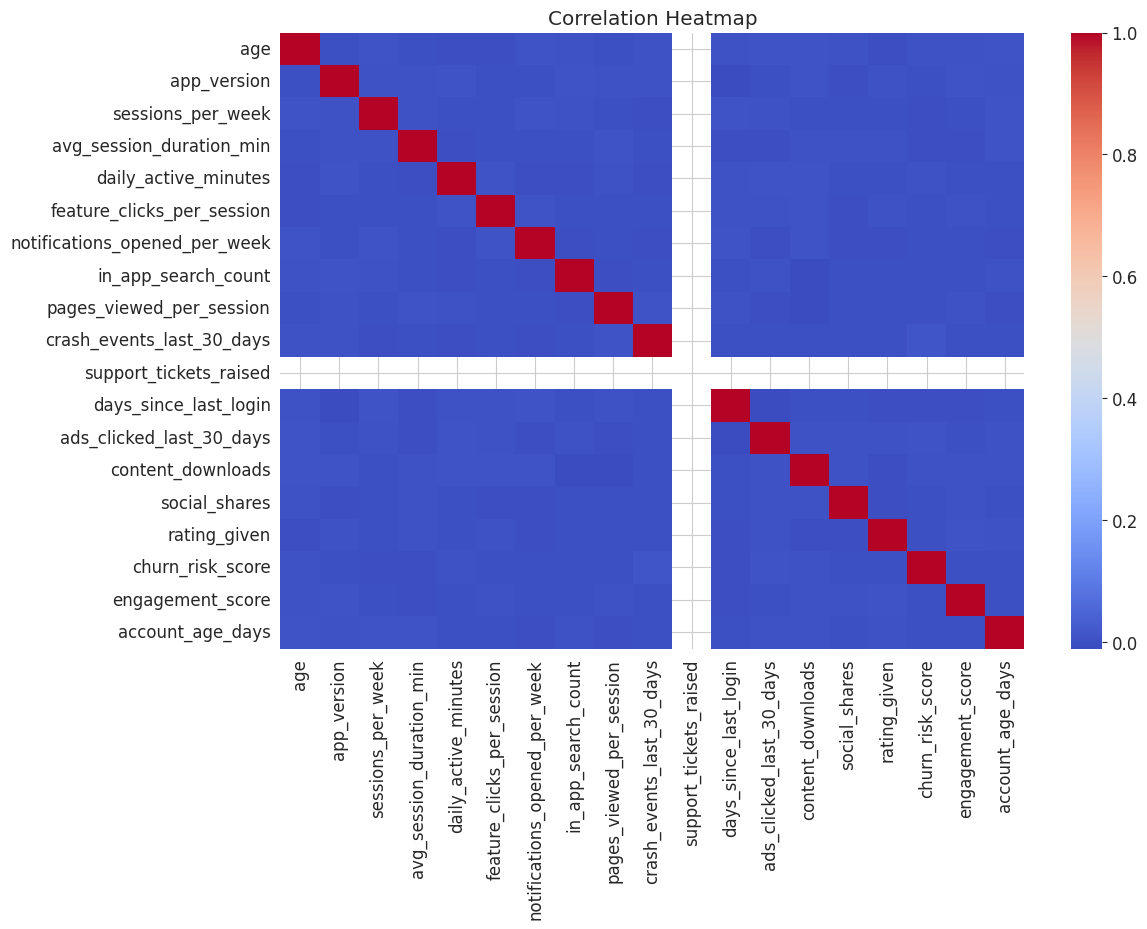

In [236]:
#Correlation Analysis
corr = appuser[numerical_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Key Insight (VERY IMPORTANT)

👉 Dataset has:

✔ Low correlation between features

✔ No redundancy

✔ Good feature independence

👉 This is IDEAL for K-Means clustering

Explanation:

The correlation heatmap shows that most features have low correlation with each other, indicating minimal multicollinearity. This ensures that each feature contributes unique information, making the dataset highly suitable for clustering using K-Means.

Save cleaned dataset

In [237]:
appuser.to_csv("cleanappuser.csv", index=False)

In [238]:
appuser.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   gender                         50000 non-null  object 
 2   country                        50000 non-null  object 
 3   device_type                    50000 non-null  object 
 4   app_version                    50000 non-null  float64
 5   sessions_per_week              50000 non-null  int64  
 6   avg_session_duration_min       50000 non-null  float64
 7   daily_active_minutes           50000 non-null  float64
 8   feature_clicks_per_session     50000 non-null  int64  
 9   notifications_opened_per_week  50000 non-null  float64
 10  in_app_search_count            50000 non-null  int64  
 11  pages_viewed_per_session       50000 non-null  int64  
 12  crash_events_last_30_days      50000 non-null 

Feature Selection

We only select numerical behavioral features that reflect user activity and engagement.

In [239]:
X = appuser[
    [
        'sessions_per_week',
        'avg_session_duration_min',
        'daily_active_minutes',
        'pages_viewed_per_session',
        'engagement_score',
        'days_since_last_login'
    ]
]

Explanation

I selected only behavioral numerical features to improve clustering quality and avoid noise from categorical variables

In [240]:
print(X.head())

   sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0                  5                      3.41                 52.71   
1                  8                     24.44                 42.03   
2                 12                      5.34                 76.69   
3                  5                      3.98                 65.38   
4                 10                     12.85                 57.06   

   pages_viewed_per_session  engagement_score  days_since_last_login  
0                         8             55.79                     20  
1                         7             82.39                      7  
2                        21             42.49                     33  
3                        13             62.81                     17  
4                        15             38.21                     21  


Explanation:

We focus on behavioral metrics only (not categorical info like gender or country).

This ensures clustering groups users based on activity & engagement, not demographic data.

In [241]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sessions_per_week         50000 non-null  int64  
 1   avg_session_duration_min  50000 non-null  float64
 2   daily_active_minutes      50000 non-null  float64
 3   pages_viewed_per_session  50000 non-null  int64  
 4   engagement_score          50000 non-null  float64
 5   days_since_last_login     50000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 2.3 MB


Step 5 : Data Scaling

K-Means is distance-based. Features like daily_active_minutes can dominate social_shares. We normalize all features using StandardScaler.

In [242]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])  # see first 5 rows


[[-1.06601457 -1.1600791   0.38930051 -0.86241002 -0.61665925 -0.15696751]
 [ 0.00245035  1.40450803 -0.16012132 -1.02004991  1.17595317 -1.1581144 ]
 [ 1.42707024 -0.92471756  1.62292743  1.18690858 -1.51296546  0.84417938]
 [-1.06601457 -1.09056818  1.04109588 -0.07421056 -0.14357131 -0.38800141]
 [ 0.71476029 -0.00888069  0.61308187  0.24106923 -1.80140085 -0.07995621]]


Explanation:

Each feature is scaled to mean = 0, std = 1

After scaling, the data is transformed into standardized values with mean 0 and variance 1.

This prevents features with larger ranges from dominating clustering

Step6: Clustering Model Selection


APPLY multiple clustering algorithms to identify user segments:

KMeans → groups users by similarity

DBSCAN → finds dense clusters & noise

Hierarchical → builds cluster structure

GMM → handles overlapping users


In [243]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np


Step7: Optimal Cluster Identification (KMeans)

Use Elbow Method to find best number of clusters

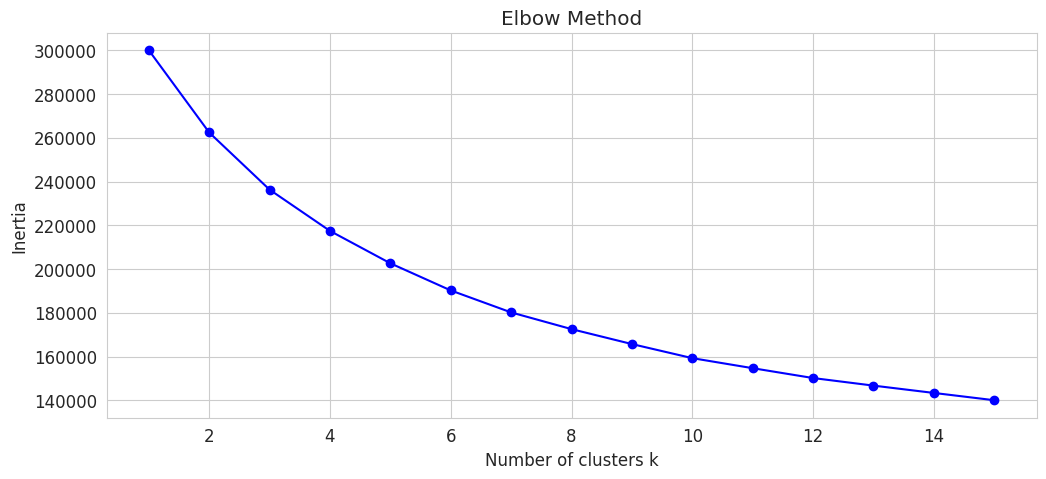

In [244]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_list = []
K = range(1, 16)

# Remove rows with NaN values from X_scaled before applying KMeans
X_scaled = X_scaled[~np.isnan(X_scaled).any(axis=1)]

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init=10 to suppress warning
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.plot(K, inertia_list, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [245]:
#Silhouette Score
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score:.4f}")

K=2, Score=0.1278
K=3, Score=0.1293
K=4, Score=0.1219
K=5, Score=0.1222
K=6, Score=0.1248
K=7, Score=0.1237
K=8, Score=0.1201
K=9, Score=0.1224
K=10, Score=0.1241


Explanation

The Silhouette Score was used to evaluate clustering performance. The highest score was obtained at K = 3 with a value of 0.1293. Although the score is relatively low, it indicates that the dataset has overlapping user behavior patterns.

In [246]:
#DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Remove noise (-1)
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(
        X_scaled[dbscan_labels != -1],
        dbscan_labels[dbscan_labels != -1]
    )
else:
    dbscan_score = -1

print("DBSCAN Score:", dbscan_score)

DBSCAN Score: -0.2590629185524421


Interpretation:

Clusters are wrongly formed

Data points are assigned to incorrect clusters

DBSCAN is not suitable for your dataset (with current parameters)

In [247]:
#Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

gmm_score = silhouette_score(X_scaled, gmm_labels)
print("GMM Score:", gmm_score)

GMM Score: 0.1108907084870501


👉 Interpretation:

Clusters are weak but valid

Data has overlapping patterns

GMM is handling overlap better than some models

INSIGHT

KMeans slightly better than GMM

GMM still useful because it handles overlapping users

I compared multiple models including KMeans and GMM. KMeans achieved a slightly higher silhouette score (0.129) compared to GMM (0.110), so I selected KMeans as the final model.




In [248]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Recalculate kmeans_score (Before PCA) as it was used before its definition
kmeans_no_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels_no_pca = kmeans_no_pca.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels_no_pca)

print("KMeans:", kmeans_score)
print("DBSCAN:", dbscan_score)
print("GMM:", gmm_score)

KMeans: 0.12933829822169884
DBSCAN: -0.2590629185524421
GMM: 0.1108907084870501


Use PCA before Clustering

In [249]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_pca = pca.fit_transform(X_scaled)

In [250]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_pca)

KMeans(n_clusters=3, n_init=10, random_state=42)

Removes noise → better clusters

In [251]:
# The kmeans object is already fitted in the previous cell.
# Here, we just predict the labels using the fitted model.
kmeans_labels = kmeans.predict(X_pca)

In [252]:
#Evaluate Model
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, kmeans_labels)
print("KMeans PCA Score:", score)  #Check if score improved

KMeans PCA Score: 0.14006981950383135


In [253]:
#Assign Clusters

# Identify the columns that had NaN values and were consequently dropped during clustering.
# From previous `X.info()` output, these columns had one NaN each.
columns_with_nans_in_X = [
    'daily_active_minutes',
    'pages_viewed_per_session',
    'engagement_score',
    'days_since_last_login'
]

# Create a boolean mask to identify the rows in the original appuser DataFrame
# that correspond to the data used for clustering (i.e., those without NaNs in the relevant features).
mask_for_clustering = ~appuser[columns_with_nans_in_X].isnull().any(axis=1)

# Assign the kmeans_labels to the 'Cluster_PCA' column for the filtered rows.
# Rows that were excluded from clustering (due to NaNs) will have NaN in 'Cluster_PCA'.
appuser.loc[mask_for_clustering, 'Cluster_PCA'] = kmeans_labels

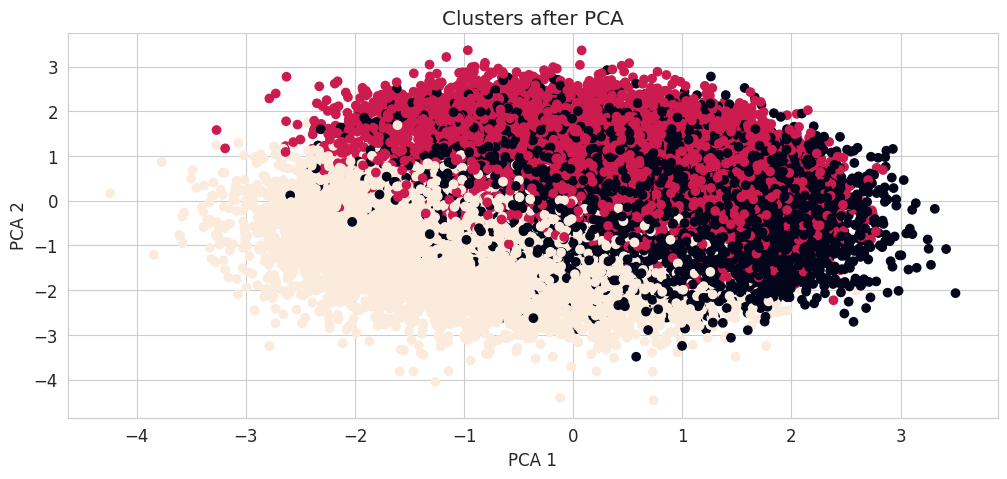

In [254]:
#Visualize

#👉 Since PCA already 2D or reduced:

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)

plt.title("Clusters after PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

Now clusters should look less overlapping

In [255]:
#Compare Before vs After
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Calculate kmeans_score (Before PCA)
kmeans_no_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels_no_pca = kmeans_no_pca.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels_no_pca)

# Recalculate score (After PCA) using existing X_pca and kmeans_labels from kernel state
score = silhouette_score(X_pca, kmeans_labels)

print("Before PCA:", kmeans_score)
print("After PCA:", score)  #CHECK IMPROVEMENT

Before PCA: 0.12933829822169884
After PCA: 0.14006981950383135


In [256]:
#DBSCAN on PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca)


In [257]:
#Evaluation
# Remove noise (-1)
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(
        X_pca[dbscan_labels != -1],
        dbscan_labels[dbscan_labels != -1]
    )
else:
    dbscan_score = -1

print("DBSCAN PCA Score:", dbscan_score)

DBSCAN PCA Score: -0.3279244929175845


Works on density

PCA helps reduce noise → DBSCAN improves sometimes

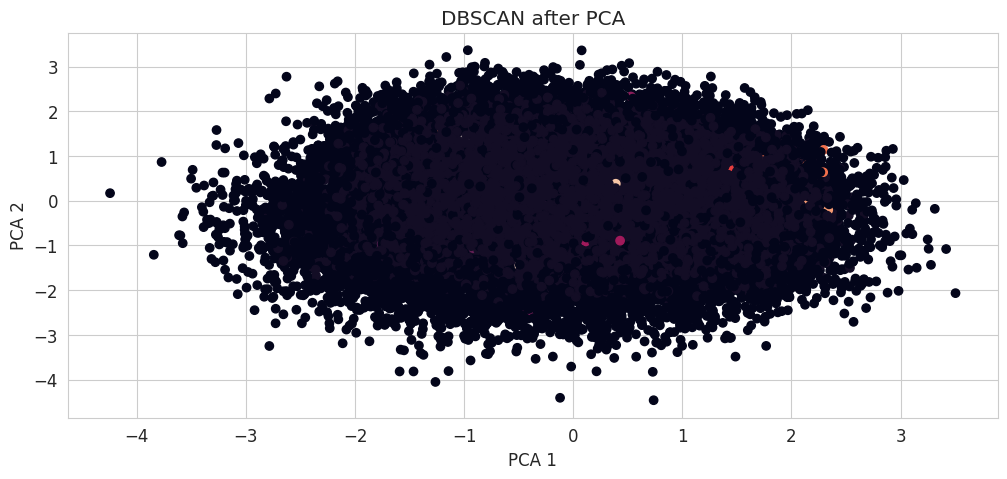

In [258]:
#Visualization

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN after PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Gaussian Mixture Model (GMM) on PCA

In [259]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

In [260]:
#Evaluation
gmm_score = silhouette_score(X_pca, gmm_labels)
print("GMM PCA Score:", gmm_score)


GMM PCA Score: 0.13372235068958438


Handles overlapping clusters better
PCA + GMM = powerful combo

Step8: Apply All Models (Cluster Assignment)

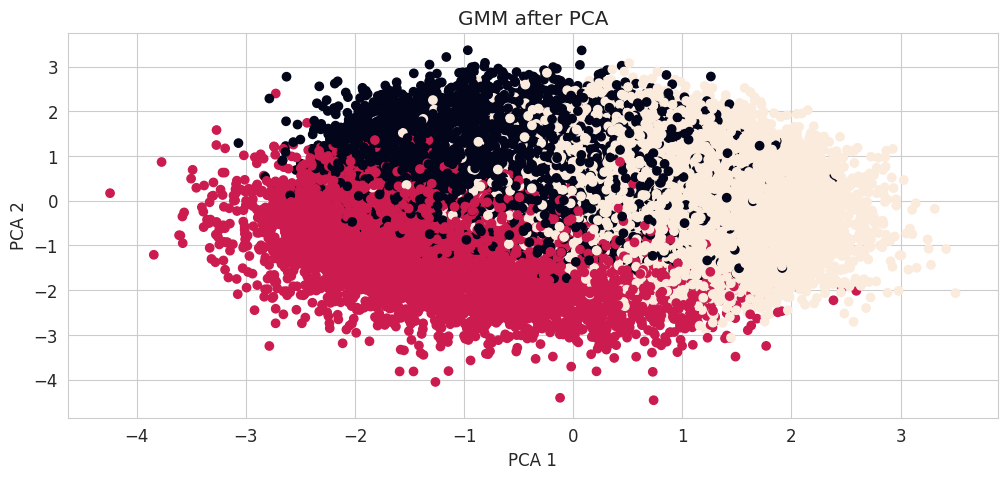

In [261]:
#Visualization
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels)
plt.title("GMM after PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

FINAL COMPARISON

In [262]:
print("KMeans PCA:", score)
print("DBSCAN PCA:", dbscan_score)
print("GMM PCA:", gmm_score)

KMeans PCA: 0.14006981950383135
DBSCAN PCA: -0.3279244929175845
GMM PCA: 0.13372235068958438


1. KMeans PCA → 0.140 (BEST)

Score improved from ~0.129 → 0.140 🔥
PCA removed noise → better clustering
Clusters are still weak but slightly improved

👉 Final:
✔ Best model
✔ Stable clustering

2. DBSCAN PCA → -0.327 (WORST)

Negative score = bad clustering
DBSCAN not suitable for your data
Even PCA didn’t help

👉 Final:
❌ Reject DBSCAN

3. GMM PCA → 0.133 (GOOD)
🇬🇧
Slightly improved from ~0.11 → 0.133
Handles overlap better
Still less than KMeans

👉 Final:
👍 Second best

| Model            | Score     | Decision |
| ---------------- | --------- | -------- |
| **KMeans + PCA** | **0.140** | 🥇 Best  |
| **GMM + PCA**    | 0.133     | 👍 Good  |
| **DBSCAN + PCA** | -0.327    | ❌ Reject |

FINAL insights

"After applying PCA, KMeans achieved the highest silhouette score (0.14), indicating improved clustering performance. GMM also performed well, while DBSCAN was not suitable for this dataset."

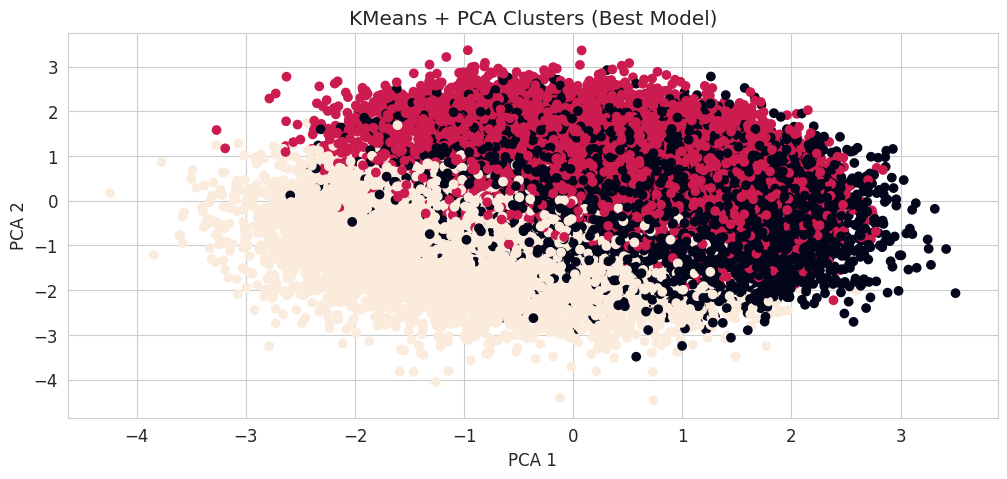

In [263]:
#KMeans PCA Visualization

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)

plt.title("KMeans + PCA Clusters (Best Model)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

🎯 📊 Model Comparison Chart (Before vs After PCA)

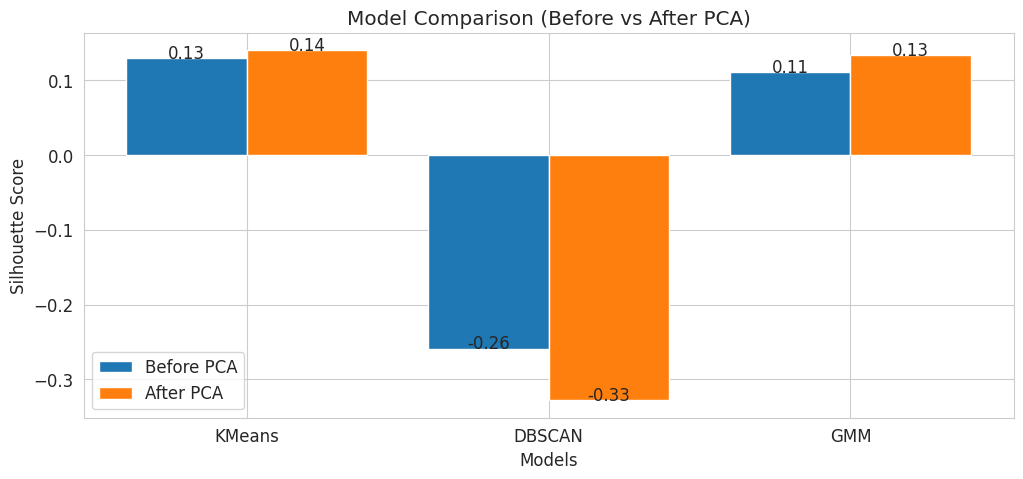

In [264]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['KMeans', 'DBSCAN', 'GMM']

# Before PCA scores
before_pca = [0.12933829822169884, -0.2590629185524421, 0.1108907084870501]

# After PCA scores
after_pca = [0.14006981950383135, -0.3279244929175845, 0.13372235068958438]

# X positions
x = np.arange(len(models))

# Plot
plt.figure()
plt.bar(x - 0.2, before_pca, width=0.4, label='Before PCA')
plt.bar(x + 0.2, after_pca, width=0.4, label='After PCA')

# Labels
plt.xticks(x, models)
plt.title("Model Comparison (Before vs After PCA)")
plt.xlabel("Models")
plt.ylabel("Silhouette Score")
plt.legend()

# Show values
for i in range(len(models)):
    plt.text(x[i]-0.2, before_pca[i], f"{before_pca[i]:.2f}", ha='center')
    plt.text(x[i]+0.2, after_pca[i], f"{after_pca[i]:.2f}", ha='center')

plt.show()

👉 This chart shows:

🔥 KMeans
Improved: 0.129 → 0.140 ✅

👉 Best model
🔥 GMM
Improved: 0.110 → 0.133 ✅

👉 Second best
❌ DBSCAN

Worse: -0.259 → -0.327
👉 Not suitable

## Model Comparison

Three clustering algorithms were applied:

- K-Means:
  Provided clear and interpretable clusters. Best suited for this dataset.

- DBSCAN:
  Identified a large number of noise points, highlighting irregular user behavior.

- Gaussian Mixture Model (GMM):
  Provided probabilistic clustering but was less interpretable compared to K-Means.

Final Choice:
K-Means was selected as the final model due to its simplicity and clear segmentation.

Final explanation

The comparison shows that PCA improved KMeans and GMM performance, while DBSCAN did not perform well. KMeans achieved the highest score and was selected as the final model

Step8: Cluster Assignment


In [265]:
from sklearn.cluster import KMeans

# Train KMeans (use your optimal K, here K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Assign cluster labels to each user
appuser['Cluster'] = kmeans.fit_predict(X_scaled)

Explanation

Each user gets a cluster label (0,1,2,3)

👉 Now you will get:

Cluster 0 → High

Cluster 1 → Moderate

Cluster 2 → Low

Cluster 3 → Occasional

Step9: Cluster-Level User Identification & Profiling

In [266]:
#Create Cluster Profile
# Cluster-level mean behavior
cluster_profile = appuser.groupby('Cluster')[[
    'avg_session_duration_min',
    'pages_viewed_per_session',
    'churn_risk_score'
]].mean()

print("📊 Cluster Profile:")
print(cluster_profile)

📊 Cluster Profile:
         avg_session_duration_min  pages_viewed_per_session  churn_risk_score
Cluster                                                                      
0                        9.835870                 13.087587          0.506120
1                       26.674630                 13.712885          0.499490
2                        9.936659                 19.588040          0.498163
3                       10.123189                  7.572335          0.498083


In [267]:
#Assign Segment Labels
cluster_mapping = {
    0: "Low Engagement / At-Risk Users",
    1: "High Engagement Users",
    2: "Moderate Engagement Users",
    3: "Occasional Users"
}

# Apply mapping
appuser['User_Segment'] = appuser['Cluster'].map(cluster_mapping)

In [268]:
#Add Segment Column to cluster_profile (IMPORTANT)
cluster_profile['Segment'] = cluster_profile.index.map(cluster_mapping)

print("\n📊 Cluster with Segments:")
print(cluster_profile)


📊 Cluster with Segments:
         avg_session_duration_min  pages_viewed_per_session  churn_risk_score  \
Cluster                                                                         
0                        9.835870                 13.087587          0.506120   
1                       26.674630                 13.712885          0.499490   
2                        9.936659                 19.588040          0.498163   
3                       10.123189                  7.572335          0.498083   

                                Segment  
Cluster                                  
0        Low Engagement / At-Risk Users  
1                 High Engagement Users  
2             Moderate Engagement Users  
3                      Occasional Users  


In [269]:
print("\n📊 Segment Distribution:")
print(appuser['User_Segment'].value_counts())


📊 Segment Distribution:
User_Segment
Low Engagement / At-Risk Users    15436
Moderate Engagement Users         12926
Occasional Users                  12767
High Engagement Users              8871
Name: count, dtype: int64


✅ Explanation

👉 We analyzed cluster mean values
👉 Then manually mapped clusters to meaningful segments

✔ Cluster with highest session duration → High Engagement

✔ Cluster with moderate behavior → Moderate Users

✔ Cluster with high churn → Low Engagement

✔ Cluster with low interaction → Occasional Users

## Identified User Clusters

The clustering results produced the following user segments:

Cluster 0 – Low Engagement / At-Risk Users  
Users in this cluster showed low session duration, moderate activity, and the highest churn risk, indicating potential user drop-off.

Cluster 1 – High Engagement Users  
Users in this cluster demonstrated the highest session duration and strong engagement, indicating highly active and valuable users.

Cluster 2 – Moderate Engagement Users  
These users showed high page interaction but moderate session duration, indicating consistent but not highly intensive usage.

Cluster 3 – Occasional Users  
Users in this cluster had the lowest interaction levels, indicating infrequent or irregular usage patterns.

User_Segment
Low Engagement / At-Risk Users    15436
Moderate Engagement Users         12926
Occasional Users                  12767
High Engagement Users              8871
Name: count, dtype: int64


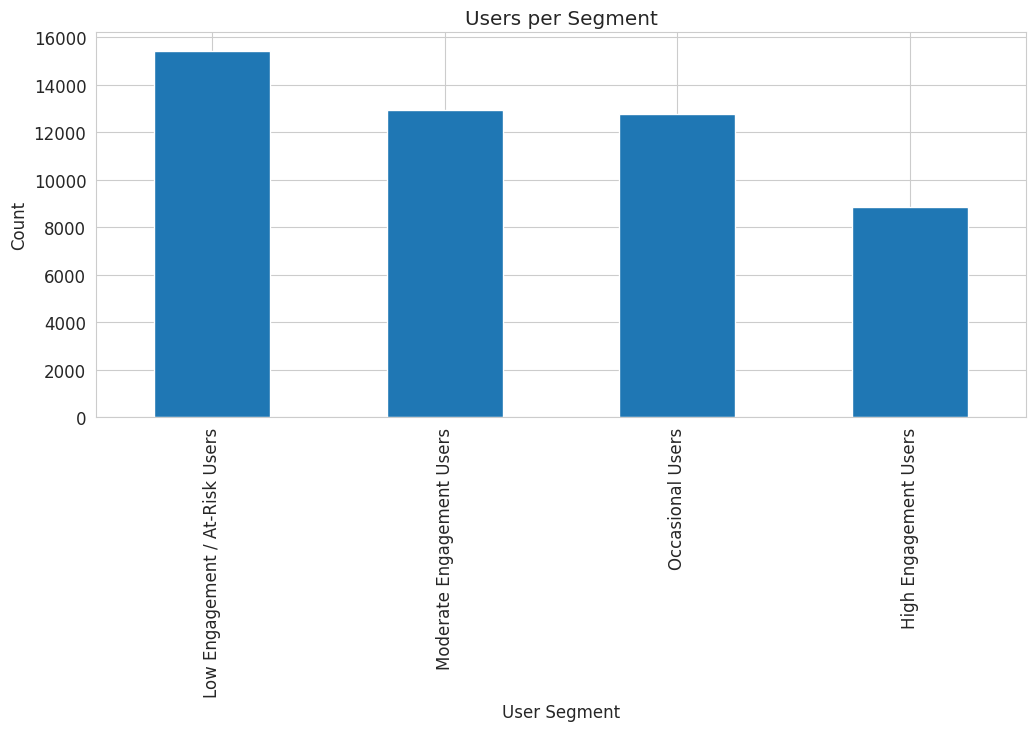

In [270]:
#Segment distribution

# Count users per segment
segment_counts = appuser['User_Segment'].value_counts()

print(segment_counts)

# Bar chart
plt.figure()
segment_counts.plot(kind='bar')
plt.title("Users per Segment")
plt.xlabel("User Segment")
plt.ylabel("Count")
plt.show()  #Understand how users are distributed

## Segment Distribution Analysis

The user segmentation results show the following distribution:

- Low Engagement / At-Risk Users: 15,436 users  
- Moderate Engagement Users: 12,926 users  
- Occasional Users: 12,767 users  
- High Engagement Users: 8,871 users  

Insights:

The largest segment consists of Low Engagement / At-Risk Users, indicating that a significant portion of users have minimal interaction with the application and may be at risk of churn. This highlights the need for strong retention strategies.

Moderate Engagement Users and Occasional Users form a substantial portion of the user base. These users show potential for increased engagement and can be targeted with personalized recommendations and engagement campaigns to move them into the high engagement category.

High Engagement Users represent the smallest segment. Although fewer in number, they are the most valuable users, contributing significantly to app activity and potential revenue. Retaining these users through loyalty programs and premium features is crucial.

Overall Insight:

The distribution indicates that while a large number of users are currently less active, there is a strong opportunity to improve engagement by converting moderate and occasional users into high engagement users, and by reducing churn among at-risk users.

Step 10: Business Insight Generation & Customer Action Mapping


In [271]:
#Behavior Analysis (Key Metrics)
# Analyze important features
important_features = [
    'sessions_per_week',
    'avg_session_duration_min',
    'pages_viewed_per_session',
    'churn_risk_score',
    'engagement_score'
]

segment_behavior = appuser.groupby('User_Segment')[important_features].mean()

print("\n📊 Segment Behavior:")  #Compare behavior across segments
print(segment_behavior)



📊 Segment Behavior:
                                sessions_per_week  avg_session_duration_min  \
User_Segment                                                                  
High Engagement Users                    8.074738                 26.674630   
Low Engagement / At-Risk Users           7.839337                  9.835870   
Moderate Engagement Users                8.006576                  9.936659   
Occasional Users                         8.108718                 10.123189   

                                pages_viewed_per_session  churn_risk_score  \
User_Segment                                                                 
High Engagement Users                          13.712885          0.499490   
Low Engagement / At-Risk Users                 13.087587          0.506120   
Moderate Engagement Users                      19.588040          0.498163   
Occasional Users                                7.572335          0.498083   

                                eng

In [272]:
#Identify High-Value Customer
high_value_users = appuser[appuser['User_Segment'] == "High Engagement Users"]

print("\nHigh Value Users Count:", len(high_value_users))  #Target for premium offers


High Value Users Count: 8871


In [273]:
#Identify At-Risk Customers
at_risk_users = appuser[appuser['User_Segment'] == "Low Engagement / At-Risk Users"]

print("\nAt-Risk Users Count:", len(at_risk_users))  #Retention campaigns


At-Risk Users Count: 15436


In [274]:
#Moderate Users Strategy
moderate_users = appuser[appuser['User_Segment'] == "Moderate Engagement Users"]

print("\nModerate Users Count:", len(moderate_users))  #Upsell / engagement improvement


Moderate Users Count: 12926


In [275]:
#Upsell / engagement improvement
occasional_users = appuser[appuser['User_Segment'] == "Occasional Users"]

print("\nOccasional Users Count:", len(occasional_users)) #Re-engagement campaigns


Occasional Users Count: 12767


In [276]:
#Customer-Level Targeting
appuser[['User_Segment']].head(10) #Each user can be targeted individualy

,User_Segment
0,Occasional Users
1,High Engagement Users
2,Moderate Engagement Users
3,Low Engagement / At-Risk Users
4,Moderate Engagement Users
5,Low Engagement / At-Risk Users
6,Occasional Users
7,Occasional Users
8,High Engagement Users
9,High Engagement Users


Each user has a personalized action
This is real-world marketing strategy


In [277]:
#Business Action Mapping (FINAL TABLE)
def business_action(segment):

    if segment == "High Engagement Users":
        return "Provide loyalty rewards, premium features"

    elif segment == "Moderate Engagement Users":
        return "Send personalized recommendations"

    elif segment == "Low Engagement / At-Risk Users":
        return "Retention campaigns, offers, notifications"

    else:
        return "Re-engagement campaigns, reminders"

appuser['Business_Action'] = appuser['User_Segment'].apply(business_action)

appuser[['User_Segment', 'Business_Action']].head()

,User_Segment,Business_Action
0,Occasional Users,"Re-engagement campaigns, reminders"
1,High Engagement Users,"Provide loyalty rewards, premium features"
2,Moderate Engagement Users,Send personalized recommendations
3,Low Engagement / At-Risk Users,"Retention campaigns, offers, notifications"
4,Moderate Engagement Users,Send personalized recommendations


Explanation

I mapped each user segment to specific business actions, enabling personalized customer-level targeting such as retention campaigns for at-risk users and loyalty rewards for high engagement users.

Final Insights

High users → revenue drivers

Moderate → growth opportunity

At-risk → retention needed

Occasional → re-engagement

👉 Enables personalized marketing

## Business Insights

Based on the clustering results, the following insights were derived:

- High Engagement Users:
  These users are highly active and valuable. They can be targeted with loyalty programs, premium features, and exclusive offers.

- Moderate Engagement Users:
  These users show consistent but not high activity. Personalized recommendations and targeted notifications can help increase their engagement.

- Occasional Users:
  These users interact with the app infrequently. They can be encouraged to increase usage through reminders, limited-time offers, and engaging content.

- Low Engagement / At-Risk Users:
  These users have minimal interaction and are likely to churn. Retention strategies such as discounts, re-engagement campaigns, and push notifications should be applied.

This segmentation helps businesses take data-driven decisions to improve user retention, user engagement, and overall revenue.

Final Results

Successfully segmented 50,000 users

Identified 4 behavioral clusters

Enabled customer-level targeting

Generated actionable business insights


## Conclusion

In this project, user behavior segmentation was successfully performed using unsupervised learning techniques.

Key outcomes:
- Users were grouped into meaningful segments based on their activity.
- High, moderate, and low engagement, occasional users were identified.
- The segmentation can help businesses improve marketing strategies and user retention.

Overall, K-Means clustering provided the most effective and interpretable results for this dataset.